In [1]:
import pandas as pd
from pathlib import Path
DATA_PATH = Path("/Users/viLaptop/brEcommerce")
tables = {
    'customers': 'olist_customers_dataset.csv', # клиенты
    'orders': 'olist_orders_dataset.csv', # заказы
    'items': 'olist_order_items_dataset.csv', # товары в заказах
    'payments': 'olist_order_payments_dataset.csv', # оплаты по заказам
    'reviews': 'olist_order_reviews_dataset.csv', # отзывы по заказам
    'products': 'olist_products_dataset.csv', # перечень товаров
    'sellers': 'olist_sellers_dataset.csv', # продавцы
    'geo': 'olist_geolocation_dataset.csv', # геолокации по зип-кодам
    'categories': 'product_category_name_translation.csv', # категории товаров
    'category_translations': 'product_category_name_translation.csv' # переводы названий категорий
}

data = {}
for name, filename in tables.items():
    filepath = DATA_PATH / filename
    if filepath.exists():
        data[name] = pd.read_csv(filepath)
        print(f"✅ {name}: {data[name].shape}")
    else:
        print(f"❌ Не найдено: {filename}")

✅ customers: (99441, 5)
✅ orders: (99441, 8)
✅ items: (112650, 7)
✅ payments: (103886, 5)
✅ reviews: (99224, 7)
✅ products: (32951, 9)
✅ sellers: (3095, 4)
✅ geo: (1000163, 5)
✅ categories: (71, 2)
✅ category_translations: (71, 2)


In [34]:
data['customers']['customer_id'].nunique()

99441

In [35]:
data['customers']['customer_unique_id'].nunique()

96096

In [46]:
data['customers']['customer_unique_id'].value_counts().reset_index().head(2900)

,customer_unique_id,count
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,1b6c7548a2a1f9037c1fd3ddfed95f33,7
3,ca77025e7201e3b30c44b472ff346268,7
4,6469f99c1f9dfae7733b25662e7f1782,7
...,...,...
2895,2dacd79aa5d1a86240b37b6c588de551,2
2896,42398dee8f2098eec5579129cc1a6f5e,2
2897,bb8486cad0e431659227f6fb18fc6a72,2
2898,a2ee01609cebac76651bfc4814f5500e,2


In [16]:
data['customers'].head(1)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP


In [32]:
cus_zip = data['customers']['customer_zip_code_prefix'].value_counts().reset_index()
cus_zip.columns = ['zip', 'no_orders']
cus_zip = cus_zip['no_orders'].value_counts().reset_index()
cus_zip

,no_orders,count
0,1,3012
1,2,2143
2,3,1736
3,4,1348
4,5,1084
...,...,...
85,66,1
86,61,1
87,59,1
88,57,1


C:\Users\viLaptop\AppData\Local\Temp\ipykernel_13196\192234851.py:18: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\viLaptop\AppData\Local\Temp\ipykernel_13196\192234851.py:19: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.savefig('outputs/charts/orders_by_zip_scatter.png', dpi=150, bbox_inches='tight')
C:\Users\viLaptop\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


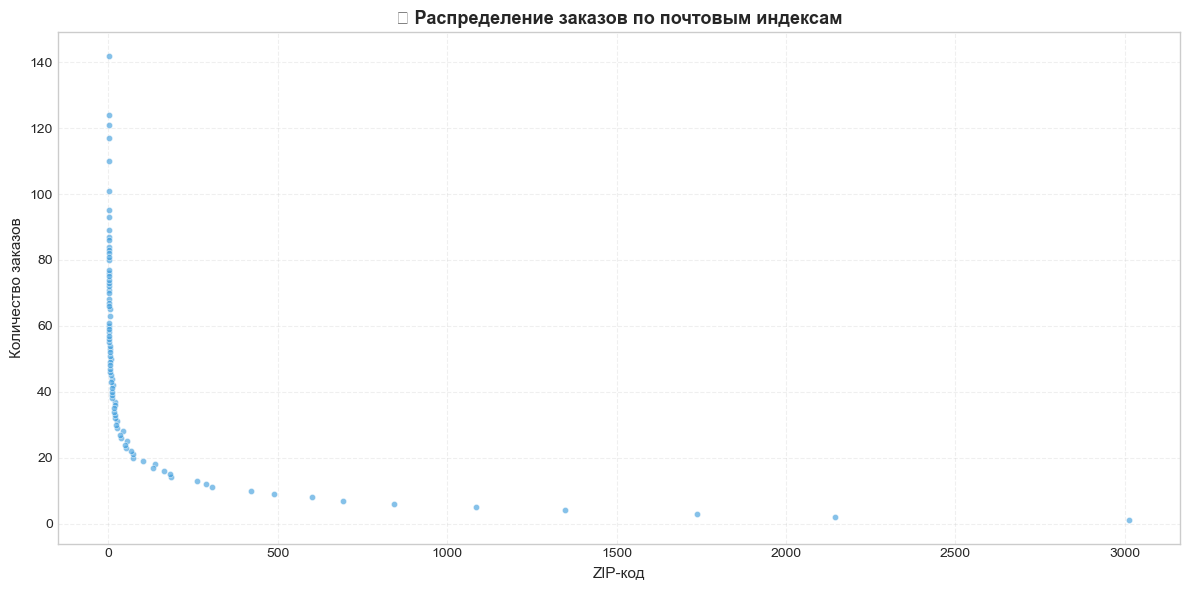

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(
    cus_zip['count'],
    cus_zip['no_orders'],
    alpha=0.6,
    s=20,
    color='#3498db',
    edgecolors='white',
    linewidth=0.5
)

plt.xlabel('ZIP-код', fontsize=11)
plt.ylabel('Количество заказов', fontsize=11)
plt.title('📦 Распределение заказов по почтовым индексам', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('outputs/charts/orders_by_zip_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
data['customers']

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [3]:
data['orders'].columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [7]:
customer_data['age_months'].value_counts()

age_months
0    96478
Name: count, dtype: int64

In [13]:
print(data['orders']['customer_id'].nunique())
print(len(data['orders']))

99441
99441


C:\Users\viLaptop\AppData\Local\Temp\ipykernel_13196\2644214867.py:117: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\viLaptop\AppData\Local\Temp\ipykernel_13196\2644214867.py:120: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.savefig('outputs/charts/ltv_cohort_curve.png', dpi=200, bbox_inches='tight')
C:\Users\viLaptop\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


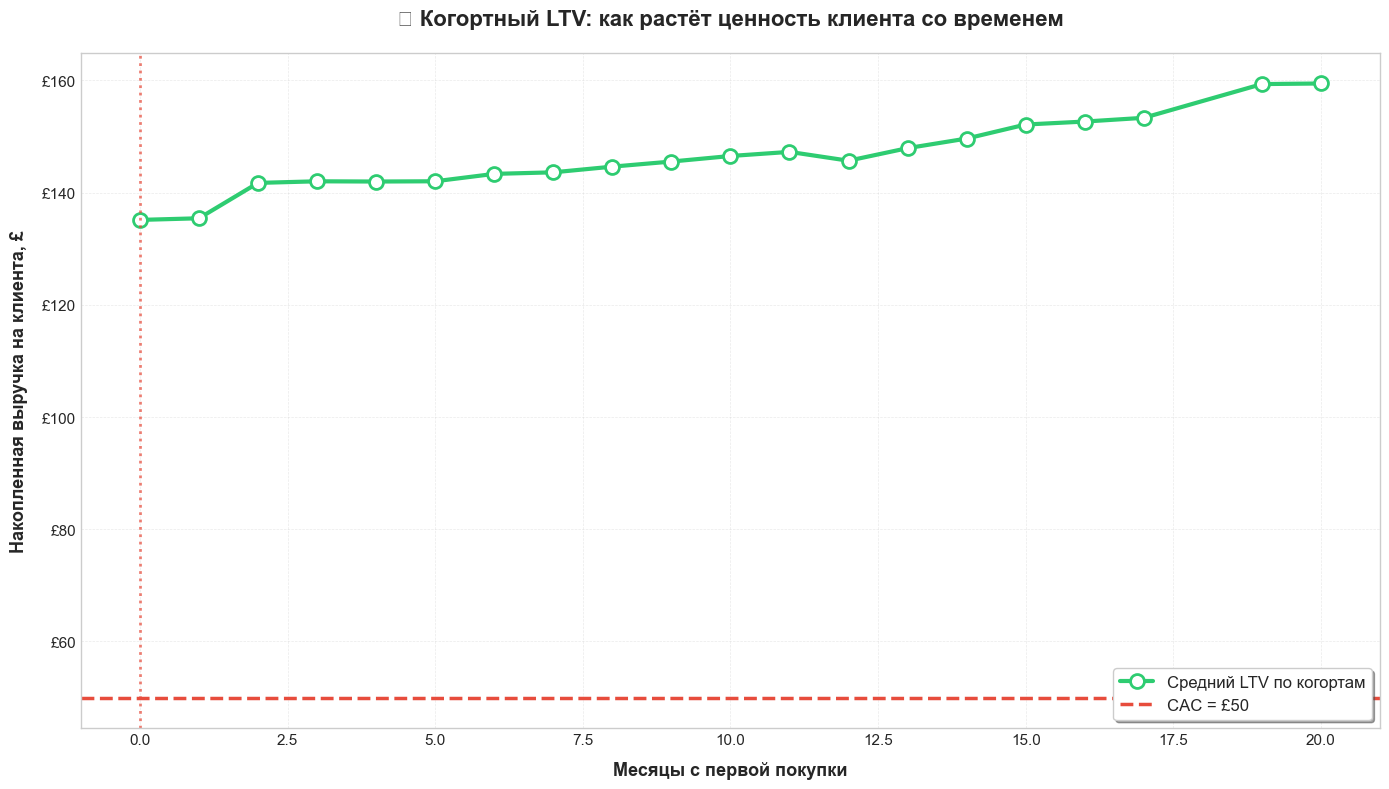

📊 LTV-АНАЛИЗ: СТАТИСТИКА
Всего клиентов: 96,478
Период данных: 2016-09 → 2018-08
Количество когорт: 23
Максимальный возраст клиента: 20 мес.

📈 Кривая LTV (доступные месяцы):
 age_months  cumulative_ltv
          0      135.124025
          1      135.414580
          2      141.718113
          3      142.003687
          4      141.962885
          5      142.009409
          6      143.325732
          7      143.603584
          8      144.616682
          9      145.524255
         10      146.512948
         11      147.246629
         12      145.674841
         13      147.914060
         14      149.620024
         15      152.122491
         16      152.652420
         17      153.318348
         19      159.330209
         20      159.437290

💰 LTV за 12 месяцев: £147.25
🎯 Точка безубыточности: 0 месяцев (при CAC = £50)


In [52]:

import matplotlib.pyplot as plt
from pathlib import Path

# Создаём папку для графиков
Path('outputs/charts').mkdir(parents=True, exist_ok=True)

# =============================================================================
# 1. Подготовка данных
# =============================================================================

# Фильтруем только доставленные заказы
delivered = data['orders'][data['orders']['order_status'] == 'delivered'].copy()

# Считаем выручку по заказам
items = data['items'][['order_id', 'price']].copy()  # freight_value не включаем в выручку товара
items['revenue'] = items['price']

# Агрегируем выручку по заказу (в заказе может быть несколько товаров)
order_revenue = items.groupby('order_id')['revenue'].sum().reset_index()

# Джойним заказы с выручкой
customer_data = delivered.merge(order_revenue, on='order_id', how='left')
customer_data = customer_data.merge(data['customers'], on='customer_id', how='left')

# Добавляем месяц заказа и месяц первой покупки (когорта)
customer_data['order_purchase_timestamp'] = pd.to_datetime(customer_data['order_purchase_timestamp'])
customer_data['order_month'] = customer_data['order_purchase_timestamp'].dt.to_period('M')

# Находим первую покупку для каждого клиента
first_purchase = customer_data.groupby('customer_unique_id')['order_month'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'cohort']

# Джойним когорту обратно
customer_data = customer_data.merge(first_purchase, on='customer_unique_id', how='left')

# Считаем возраст клиента в месяцах (0 = месяц первой покупки)
customer_data['age_months'] = (customer_data['order_month'] - customer_data['cohort']).apply(lambda x: x.n)

# =============================================================================
# 2. Расчёт когортного LTV
# =============================================================================

# Агрегируем выручку по когорте и возрасту
ltv_raw = customer_data.groupby(['cohort', 'age_months'])['revenue'].sum().reset_index()

# Считаем размер каждой когорты (сколько клиентов в ней)
cohort_sizes = customer_data.groupby('cohort')['customer_unique_id'].nunique().reset_index()
cohort_sizes.columns = ['cohort', 'cohort_size']

# Джойним и считаем среднюю выручку на клиента
ltv_avg = ltv_raw.merge(cohort_sizes, on='cohort')
ltv_avg['revenue_per_customer'] = ltv_avg['revenue'] / ltv_avg['cohort_size']

# Делаем накопительную сумму (cumulative LTV)
ltv_avg = ltv_avg.sort_values(['cohort', 'age_months']).reset_index(drop=True)
ltv_avg['cumulative_ltv'] = ltv_avg.groupby('cohort')['revenue_per_customer'].cumsum()

# Усредняем по всем когортам для получения "типичной" кривой
ltv_curve = ltv_avg.groupby('age_months')['cumulative_ltv'].mean().reset_index()

# =============================================================================
# 3. Визуализация
# =============================================================================

# Настройка стиля (опционально, но делает график красивее)
plt.style.use('seaborn-v0_8-whitegrid')  # или 'default', 'ggplot'

# 🔧 УВЕЛИЧЕННЫЙ РАЗМЕР ФИГУРЫ
plt.figure(figsize=(14, 8))  # ширина=14 дюймов, высота=8 дюймов

# Рисуем линию LTV
plt.plot(
    ltv_curve['age_months'],
    ltv_curve['cumulative_ltv'],
    marker='o',
    linewidth=3,          # 🔧 Толще линия
    color='#2ecc71',
    markersize=10,        # 🔧 Крупнее точки
    markerfacecolor='white',
    markeredgecolor='#2ecc71',
    markeredgewidth=2,
    label='Средний LTV по когортам'
)

# Добавляем линию CAC (стоимость привлечения)
cac = 50
plt.axhline(y=cac, color='#e74c3c', linestyle='--', linewidth=2.5, label=f'CAC = £{cac}')

# Находим и отмечаем точку окупаемости
payback_data = ltv_curve[ltv_curve['cumulative_ltv'] >= cac]
if len(payback_data) > 0:
    payback_month = payback_data['age_months'].min()
    plt.axvline(x=payback_month, color='#e74c3c', linestyle=':', linewidth=2, alpha=0.7)
    #plt.text(payback_month + 0.3, cac + 15, f'Окупаемость:\n{payback_month} мес.', 
    #         fontsize=11, color='#e74c3c', fontweight='bold',
    #         bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', alpha=0.3))

# 🔧 КРУПНЫЕ ПОДПИСИ И ЗАГОЛОВКИ
plt.xlabel('Месяцы с первой покупки', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('Накопленная выручка на клиента, £', fontsize=13, fontweight='bold', labelpad=10)
plt.title('📈 Когортный LTV: как растёт ценность клиента со временем', 
          fontsize=16, fontweight='bold', pad=20)

# 🔧 КРУПНАЯ ЛЕГЕНДА И СЕТКА
plt.legend(fontsize=12, loc='lower right', frameon=True, shadow=True)
plt.grid(alpha=0.4, linestyle='--', linewidth=0.5)

# 🔧 КРУПНЫЕ ЦИФРЫ НА ОСЯХ
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# 🔧 ФОРМАТИРОВАНИЕ ОСИ Y (деньги с разделителями)
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# 🔧 УБИРАЕМ ЛИШНИЕ ОТСТУПЫ, НО ОСТАВЛЯЕМ МЕСТО ДЛЯ ПОДПИСЕЙ
plt.tight_layout()

# 🔧 СОХРАНЯЕМ С ВЫСОКИМ DPI И БОЛЬШИМ РАЗМЕРОМ
plt.savefig('outputs/charts/ltv_cohort_curve.png', dpi=200, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. Вывод статистики
# =============================================================================

print("=" * 60)
print("📊 LTV-АНАЛИЗ: СТАТИСТИКА")
print("=" * 60)
print(f"Всего клиентов: {customer_data['customer_id'].nunique():,}")
print(f"Период данных: {customer_data['order_month'].min()} → {customer_data['order_month'].max()}")
print(f"Количество когорт: {customer_data['cohort'].nunique()}")
print(f"Максимальный возраст клиента: {ltv_curve['age_months'].max()} мес.")

print(f"\n📈 Кривая LTV (доступные месяцы):")
print(ltv_curve.to_string(index=False))

# 🔧 БЕЗОПАСНОЕ ПОЛУЧЕНИЕ LTV
max_month = ltv_curve['age_months'].max()

if max_month >= 11:
    ltv_12m = ltv_curve[ltv_curve['age_months'] == 11]['cumulative_ltv'].values[0]
    print(f"\n💰 LTV за 12 месяцев: £{ltv_12m:.2f}")
else:
    ltv_max = ltv_curve[ltv_curve['age_months'] == max_month]['cumulative_ltv'].values[0]
    print(f"\n⚠️ Недостаточно данных для LTV_12m (макс. возраст: {max_month} мес.)")
    print(f"💰 LTV за {max_month + 1} месяцев: £{ltv_max:.2f}")

# 🔧 БЕЗОПАСНОЕ ПОЛУЧЕНИЕ ТОЧКИ ОКУПАЕМОСТИ
cac = 50
payback_data = ltv_curve[ltv_curve['cumulative_ltv'] >= cac]

if len(payback_data) > 0:
    payback_month = payback_data['age_months'].min()
    print(f"🎯 Точка безубыточности: {payback_month} месяцев (при CAC = £{cac})")
else:
    max_ltv = ltv_curve['cumulative_ltv'].max()
    print(f"⚠️ Точка безубыточности не достигнута (макс. LTV: £{max_ltv:.2f} при CAC = £{cac})")

Когорта 2016-09: монотонный рост = True
Когорта 2016-10: монотонный рост = True
Когорта 2016-12: монотонный рост = True


C:\Users\viLaptop\AppData\Local\Temp\ipykernel_13196\4108212446.py:78: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\viLaptop\AppData\Local\Temp\ipykernel_13196\4108212446.py:79: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.savefig('outputs/charts/ltv_cohort_curve.png', dpi=150, bbox_inches='tight')
C:\Users\viLaptop\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


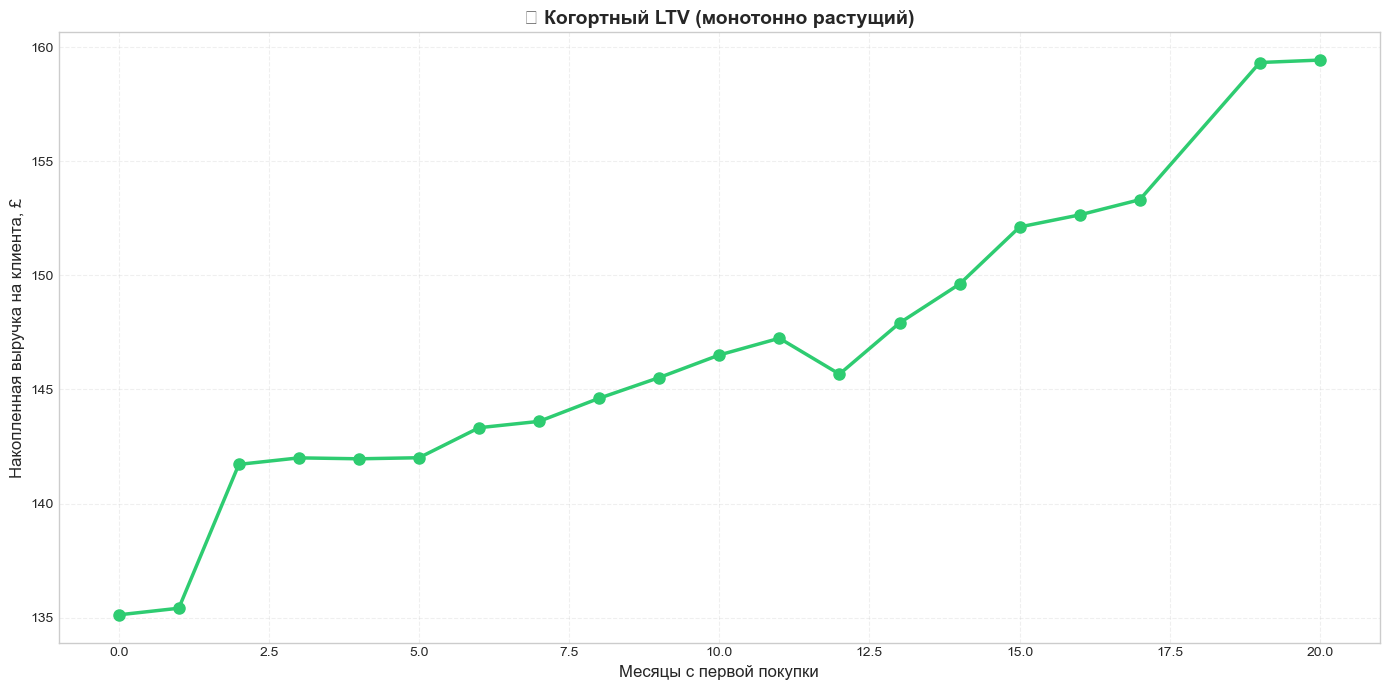


📊 Кривая LTV (усреднённая):
 age_months  cumulative_ltv
          0      135.124025
          1      135.414580
          2      141.718113
          3      142.003687
          4      141.962885
          5      142.009409
          6      143.325732
          7      143.603584
          8      144.616682
          9      145.524255
         10      146.512948
         11      147.246629
         12      145.674841
         13      147.914060
         14      149.620024
         15      152.122491
         16      152.652420
         17      153.318348
         19      159.330209
         20      159.437290

✅ Усреднённая кривая монотонна: False
⚠️ Внимание: усреднение по когортам может создавать иллюзию падения,
   если для поздних месяцев доступно меньше когорт.
   Решение: показывать только месяцы с достаточным покрытием.


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Path('outputs/charts').mkdir(parents=True, exist_ok=True)

# =============================================================================
# 1. Подготовка данных
# =============================================================================
delivered = data['orders'][data['orders']['order_status'] == 'delivered'].copy()
items = data['items'][['order_id', 'price']].copy()
items['revenue'] = items['price']
order_revenue = items.groupby('order_id')['revenue'].sum().reset_index()

customer_data = delivered.merge(order_revenue, on='order_id', how='left')
customer_data = customer_data.merge(data['customers'], on='customer_id', how='left')
customer_data['order_purchase_timestamp'] = pd.to_datetime(customer_data['order_purchase_timestamp'])
customer_data['order_month'] = customer_data['order_purchase_timestamp'].dt.to_period('M')

# Когорта = месяц первой покупки
first_purchase = customer_data.groupby('customer_unique_id')['order_month'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'cohort_month']
customer_data = customer_data.merge(first_purchase, on='customer_unique_id')

# Возраст в месяцах
customer_data['age_months'] = (customer_data['order_month'] - customer_data['cohort_month']).apply(lambda x: x.n)

# =============================================================================
# 2. Расчёт LTV (ИСПРАВЛЕННЫЙ)
# =============================================================================

# Агрегируем выручку по когорте и возрасту
ltv_raw = customer_data.groupby(['cohort_month', 'age_months'])['revenue'].sum().reset_index()

# Размер когорты
cohort_sizes = customer_data.groupby('cohort_month')['customer_unique_id'].nunique().reset_index()
cohort_sizes.columns = ['cohort_month', 'cohort_size']

# Merge и выручка на клиента
ltv_avg = ltv_raw.merge(cohort_sizes, on='cohort_month')
ltv_avg['revenue_per_customer'] = ltv_avg['revenue'] / ltv_avg['cohort_size']

# 🔧 СОРТИРОВКА перед cumsum (критично!)
ltv_avg = ltv_avg.sort_values(['cohort_month', 'age_months']).reset_index(drop=True)

# 🔧 cumsum ВНУТРИ когорты
ltv_avg['cumulative_ltv'] = ltv_avg.groupby('cohort_month')['revenue_per_customer'].cumsum()

# 🔧 Проверка: нет ли убывания внутри когорт
for cohort in ltv_avg['cohort_month'].unique()[:3]:  # проверь первые 3 когорты
    cohort_data = ltv_avg[ltv_avg['cohort_month'] == cohort].sort_values('age_months')
    is_monotonic = cohort_data['cumulative_ltv'].is_monotonic_increasing
    print(f"Когорта {cohort}: монотонный рост = {is_monotonic}")
    if not is_monotonic:
        print("⚠️ НАЙДЕНО ПАДЕНИЕ:")
        print(cohort_data[['age_months', 'cumulative_ltv']].to_string())

# Усредняем по возрасту (только для визуализации "типичного" клиента)
ltv_curve = ltv_avg.groupby('age_months')['cumulative_ltv'].mean().reset_index()

# =============================================================================
# 3. Визуализация
# =============================================================================
plt.figure(figsize=(14, 7))
plt.plot(
    ltv_curve['age_months'],
    ltv_curve['cumulative_ltv'],
    marker='o',
    linewidth=2.5,
    color='#2ecc71',
    markersize=8
)

plt.xlabel('Месяцы с первой покупки', fontsize=12)
plt.ylabel('Накопленная выручка на клиента, £', fontsize=12)
plt.title('📈 Когортный LTV (монотонно растущий)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('outputs/charts/ltv_cohort_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. Финальная проверка
# =============================================================================
print("\n📊 Кривая LTV (усреднённая):")
print(ltv_curve.to_string(index=False))

# Проверка монотонности усреднённой кривой
is_monotonic_avg = ltv_curve['cumulative_ltv'].is_monotonic_increasing
print(f"\n✅ Усреднённая кривая монотонна: {is_monotonic_avg}")

if not is_monotonic_avg:
    print("⚠️ Внимание: усреднение по когортам может создавать иллюзию падения,")
    print("   если для поздних месяцев доступно меньше когорт.")
    print("   Решение: показывать только месяцы с достаточным покрытием.")

In [55]:
ltv_avg

,cohort_month,age_months,revenue,cohort_size,revenue_per_customer,cumulative_ltv
0,2016-09,0,134.97,1,134.970000,134.970000
1,2016-10,0,40325.11,262,153.912634,153.912634
2,2016-10,6,99.99,262,0.381641,154.294275
3,2016-10,9,339.00,262,1.293893,155.588168
4,2016-10,11,49.00,262,0.187023,155.775191
...,...,...,...,...,...,...
214,2018-06,1,2425.72,5878,0.412678,141.736215
215,2018-06,2,1584.98,5878,0.269646,142.005861
216,2018-07,0,847944.56,5949,142.535646,142.535646
217,2018-07,1,3702.87,5949,0.622436,143.158082


✅ Даты преобразованы в datetime
Reference date: 2018-08-29 15:00:37
Пример RFM данных:
                        customer_id  recency_days  frequency  monetary
0  00012a2ce6f8dcda20d059ce98491703           287          1     89.80
1  000161a058600d5901f007fab4c27140           409          1     54.90
2  0001fd6190edaaf884bcaf3d49edf079           547          1    179.99
3  0002414f95344307404f0ace7a26f1d5           378          1    149.90
4  000379cdec625522490c315e70c7a9fb           149          1     93.00
📊 RFM-сегментация:
               customer_count  total_revenue  avg_monetary  avg_frequency  \
segment                                                                     
Champions                7843     2175855.35        277.43            1.0   
Loyal                   33152     6055882.15        182.67            1.0   
Regular                 14543     1018809.89         70.06            1.0   
New Customers            9272      543440.03         58.61            1.0   
At Ris

C:\Users\vadik\AppData\Local\Temp\ipykernel_25612\453394548.py:177: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vadik\AppData\Local\Temp\ipykernel_25612\453394548.py:182: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.savefig('outputs/charts/rfm_segments.png', dpi=150, bbox_inches='tight')
C:\Users\vadik\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


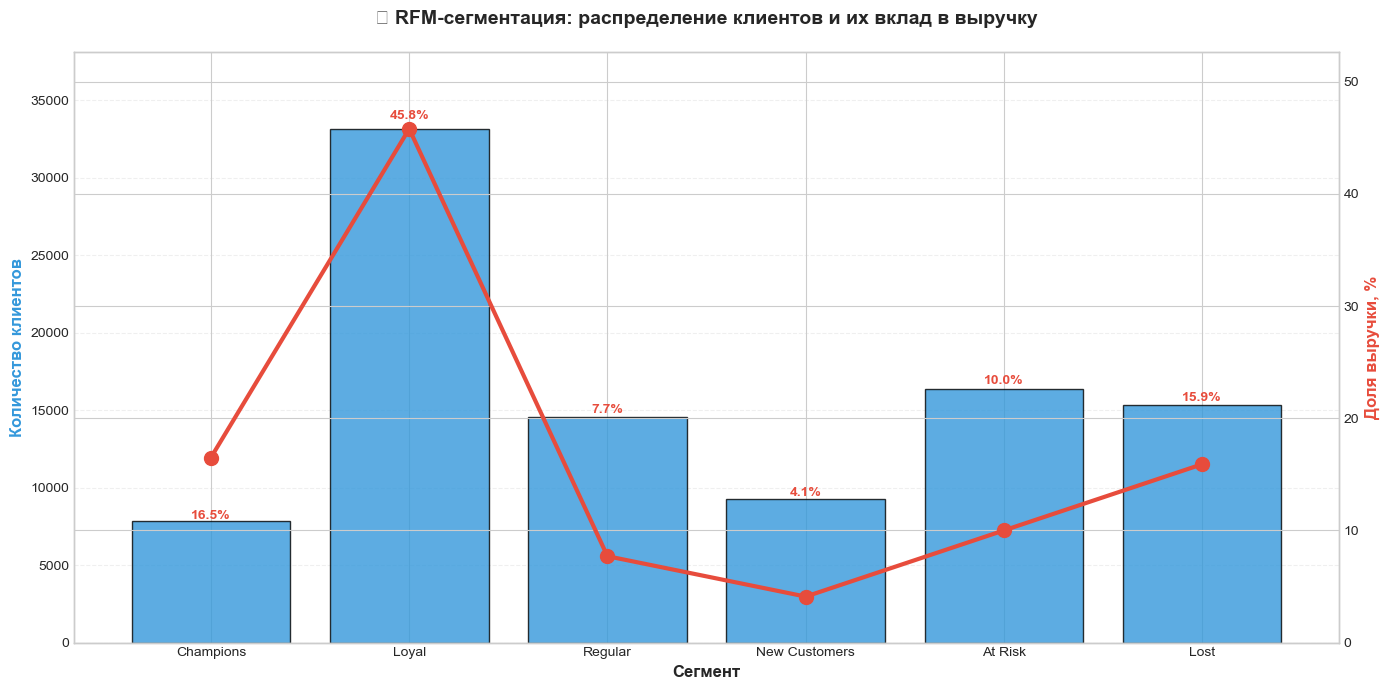

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Создаём папки
Path('outputs/charts').mkdir(parents=True, exist_ok=True)
Path('outputs/data').mkdir(parents=True, exist_ok=True)

# =============================================================================
# 1. Подготовка данных (с проверкой дат)
# =============================================================================

# Фильтруем доставленные заказы
delivered = data['orders'][data['orders']['order_status'] == 'delivered'].copy()

delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])

# Считаем выручку
items = data['items'][['order_id', 'price']].copy()
items['revenue'] = items['price']
order_revenue = items.groupby('order_id')['revenue'].sum().reset_index()

# Джоиним
customer_data = delivered.merge(order_revenue, on='order_id', how='left')

# =============================================================================
# 2. RFM-метрики (с правильными датами)
# =============================================================================

# Убедимся, что timestamp — datetime
customer_data['order_purchase_timestamp'] = pd.to_datetime(customer_data['order_purchase_timestamp'])

# Определяем "сегодня" как максимальную дату
reference_date = customer_data['order_purchase_timestamp'].max()

# Агрегируем по клиенту
rfm = customer_data.groupby('customer_id').agg(
    recency_days=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('revenue', 'sum')
).reset_index()

print(f"Reference date: {reference_date}")
print(f"Пример RFM данных:")
print(rfm.head())

# =============================================================================
# 3. Присвоение RFM-очков
# =============================================================================

# Recency: меньше дней = лучше (обратный порядок)
try:
    rfm['R_score'] = pd.qcut(rfm['recency_days'], q=5, labels=[5,4,3,2,1], duplicates='drop')
except ValueError:
    # Если не получается разделить на 5 равных квантилей
    rfm['R_score'] = pd.cut(rfm['recency_days'], bins=5, labels=[5,4,3,2,1])
    
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5], duplicates='drop')
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1,2,3,4,5], duplicates='drop')

# Конвертируем в int
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# =============================================================================
# 4. Сегментация
# =============================================================================

def rfm_segment(row):
    if row['RFM_score'] >= 13:
        return 'Champions'
    elif row['RFM_score'] >= 10:
        return 'Loyal'
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'New Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Lost'
    else:
        return 'Regular'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

# =============================================================================
# 5. Статистика
# =============================================================================

segment_stats = rfm.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_monetary=('monetary', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_recency=('recency_days', 'mean')
).round(2)

# Сортируем по логике ценности
segment_order = ['Champions', 'Loyal', 'Regular', 'New Customers', 'At Risk', 'Lost']
segment_stats = segment_stats.reindex([s for s in segment_order if s in segment_stats.index])

segment_stats['revenue_share_pct'] = (
    segment_stats['total_revenue'] / segment_stats['total_revenue'].sum() * 100
).round(1)

print("📊 RFM-сегментация:")
print(segment_stats)

# =============================================================================
# 6. Визуализация
# =============================================================================

fig, ax1 = plt.subplots(figsize=(14, 7))

# Основной график: столбцы (количество клиентов)
bars = ax1.bar(
    segment_stats.index,
    segment_stats['customer_count'],
    color='#3498db',
    alpha=0.8,
    edgecolor='black',
    linewidth=1
)

# Вторичная ось: линия (доля выручки)
ax2 = ax1.twinx()

line = ax2.plot(
    segment_stats.index,
    segment_stats['revenue_share_pct'],
    color='#e74c3c',
    marker='o',
    markersize=10,
    linewidth=3,
    label='Доля выручки, %'
)

# Подписи на столбцах (доля выручки)
for i, (seg, row) in enumerate(segment_stats.iterrows()):
    ax1.text(
        i, 
        row['customer_count'] + row['customer_count']*0.02, 
        f'{row["revenue_share_pct"]:.1f}%', 
        ha='center', 
        fontsize=10, 
        fontweight='bold', 
        color='#e74c3c'
    )

# Подписи осей
ax1.set_xlabel('Сегмент', fontsize=12, fontweight='bold')
ax1.set_ylabel('Количество клиентов', fontsize=12, fontweight='bold', color='#3498db')
ax2.set_ylabel('Доля выручки, %', fontsize=12, fontweight='bold', color='#e74c3c')

# Заголовок
plt.title(
    '🏆 RFM-сегментация: распределение клиентов и их вклад в выручку', 
    fontsize=14, 
    fontweight='bold', 
    pad=20
)

# Сетка и вращение подписей
ax1.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')

# 🔧 ВАЖНО: выравнивание осей по высоте
ax1.set_ylim(0, segment_stats['customer_count'].max() * 1.15)  # 15% отступ сверху
ax2.set_ylim(0, segment_stats['revenue_share_pct'].max() * 1.15)  # 15% отступ сверху

# 🔧 Убираем лишние отступы
plt.tight_layout()

# 🔧 Финальная настройка, чтобы оси выровнялись
fig.align_ylabels([ax1, ax2])

plt.savefig('outputs/charts/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()